K-Means + Hierarchical Clustering Analysis
==============================================================
Research Questions addressed:

  Q1.  What races/ethnicities are most at risk for hypertension?

  Q2.  How significant is the risk disparity between genders?

  Q5.  At what age should one start to be concerned with hypertension?

  Q6.  Are income and education good predictors of hypertension risk?

  Q8.  Which vice first: smoking or drinking?
 
K-Means features   : age, male, bmi, poverty_income_ratio, physically_active, drinks_alcohol, ever_smoker, high_cholesterol

H-Clust features   : age, high_cholesterol, ever_smoker, physically_active, drinks_alcohol, drink_frequency_past_year, bmi, diagnosed_twice
                     
Post-hoc descriptors: race_ethnicity, male, hypertension_risk,
                      education, marital_status

In [88]:
# %pip install scikit-learn #<- uncomment as needed to install sklearn libary

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 1000)
pd.set_option("display.float_format", lambda x: f'{x:,.4f}')
sns.set_theme(style="whitegrid", context='talk')

Load Dataset

In [90]:
ht_risk_df = pd.read_csv('../data/nhanes_hypertension_risk.csv')
ht_risk_df

,participant_id,age,race_ethnicity,education,poverty_income_ratio,marital_status,diagnosed_high_bp,diagnosed_twice,on_chol_medication,bmi,waist_cm,weight_kg,height_cm,smoked_100_cigarettes,smoke_frequency,avg_drinks_per_day,time_sitting,total_cholesterol_mgdl,HDL_cholesterol_mgdl,fasting_glucose_mgdl,LDL_cholesterol_mgdl_friedewald,LDL_cholesterol_mgdl_martin,LDL_cholesterol_mgdl_nih,systolic_avg,systolic_clinical,diastolic_avg,diastolic_clinical,pulse_avg,pulse_clinical,hypertension_risk,male,ever_smoker,current_smoker,drinks_alcohol,drink_frequency_past_year,high_cholesterol,moderate_minutes_per_week,vigorous_minutes_per_week,physically_active
0,130378,43.0000,Non-Hispanic Asian,College graduate or above,5.0000,Married/Living with Partner,1,1.0000,No,27.0000,98.3000,86.9000,179.5000,1.0000,3.0000,1.3333,360.0000,264.0000,45.0000,113.0000,188.0000,190.0000,191.0000,132.6667,131.5000,96.0000,95.0000,81.0000,80.5000,1,1,1,0,1,208.0000,0,135.0000,135.0000,1
1,130379,66.0000,Non-Hispanic White,College graduate or above,5.0000,Married/Living with Partner,1,1.0000,No,33.5000,114.7000,101.8000,174.2000,1.0000,3.0000,3.0000,480.0000,214.0000,60.0000,125.3333,137.0000,135.0000,139.0000,117.0000,115.0000,78.6667,76.0000,72.0000,72.0000,1,1,1,0,1,300.0000,0,180.0000,135.0000,1
2,130380,44.0000,Other Hispanic,HS/GED or equivalent,1.4100,Married/Living with Partner,0,0.0000,Yes,29.7000,93.5000,69.4000,152.9000,2.0000,3.0000,1.0000,240.0000,187.0000,49.0000,156.0000,63.0000,90.0000,78.0000,109.0000,108.0000,78.3333,78.0000,81.3333,80.0000,1,0,0,0,1,1.0000,1,20.0000,21.9045,0
3,130386,34.0000,Mexican American,Some college or AA degree,1.3300,Married/Living with Partner,0,0.0000,No,30.2000,106.1000,90.6000,173.3000,1.0000,3.0000,2.0000,180.0000,183.0000,46.0000,100.0000,109.0000,111.0000,112.0000,115.0000,117.5000,73.6667,74.5000,62.3333,64.0000,0,1,1,0,1,104.0000,0,30.0000,6.9045,0
4,130394,51.0000,Non-Hispanic White,College graduate or above,5.0000,Married/Living with Partner,0,0.0000,No,24.4000,92.1000,76.7000,177.3000,2.0000,3.0000,1.0000,420.0000,183.0000,48.0000,88.0000,124.0000,120.0000,124.0000,110.6667,116.5000,68.0000,67.5000,79.6667,80.5000,0,1,0,0,1,24.0000,0,0.0000,120.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3557,142301,80.0000,Non-Hispanic White,College graduate or above,1.2000,Widowed/Divorced/Separated,1,1.0000,No,30.5000,79.7000,82.2000,164.3000,1.0000,3.0000,2.0000,360.0000,138.0000,48.0000,110.0000,61.0000,67.0000,65.0000,140.4444,112.1667,75.3333,72.8333,69.7778,79.0000,1,0,1,0,1,1.0000,1,76.4020,21.9045,0
3558,142303,69.0000,Non-Hispanic White,HS/GED or equivalent,0.9800,Widowed/Divorced/Separated,0,0.0000,Yes,27.9000,111.0000,70.8000,159.2000,1.0000,3.0000,0.0000,360.0000,110.0000,34.0000,160.0000,45.0000,53.0000,50.0000,127.0000,126.0000,69.3333,68.5000,75.3333,75.0000,1,0,1,0,0,0.0000,0,840.0000,95.0000,1
3559,142305,76.0000,Mexican American,<HS,2.2500,Widowed/Divorced/Separated,1,1.0000,Yes,26.4000,89.0000,60.4000,151.4000,2.0000,3.0000,1.3333,480.0000,180.0000,51.0000,132.0000,92.0000,101.0000,97.0000,143.6667,146.0000,79.3333,78.5000,70.6667,70.5000,1,0,0,0,1,17.3333,1,80.0000,21.9045,0
3560,142308,50.0000,Other Hispanic,Some college or AA degree,1.9500,Married/Living with Partner,0,0.0000,No,26.4000,98.4000,79.3000,173.3000,2.0000,3.0000,2.0000,600.0000,166.0000,42.6667,112.6667,61.3333,122.6667,88.6667,108.0000,109.0000,69.3333,71.5000,62.6667,65.0000,0,1,0,0,1,8.0000,0,45.0000,24.6030,0


Configuration Settings

In [91]:
output_dir  = "../visualizations/models"
seed = 42
max_k = 8
palette = "Set2"
 
kmeans_features = [
    "age", "male", "bmi", "poverty_income_ratio",
    "physically_active", "drinks_alcohol", 
    "ever_smoker", "high_cholesterol"
]
 
hclust_features = [
    "age", "high_cholesterol", "ever_smoker",
    "physically_active", "drinks_alcohol",
    "male", "bmi", "poverty_income_ratio"
]
 
print("=" * 65)
print("  HYPERTENSION RISK — CLUSTERING ANALYSIS")
print("=" * 65)

  HYPERTENSION RISK — CLUSTERING ANALYSIS


Additional Transformations Needed for Clustering (K-Means and Hierarchical)

In [92]:
def preprocess(data, feature_cols, scale=True):
     
    X = data[feature_cols].copy()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
 
    # label encode categorical values
    if cat_cols:
        le = LabelEncoder()
        for c in cat_cols:
            X[c] = le.fit_transform(X[c].astype(str))
 
    # scale numeric features
    if scale:
        scaler = StandardScaler()
        return scaler.fit_transform(X), X
    return X.values, X

A. K Means Clustering


In [93]:
print("━" * 65)
print("  PART A — K-MEANS CLUSTERING")
print("━" * 65)
 
X_km, df_km_clean = preprocess(ht_risk_df, kmeans_features, scale=True)
print(f"  Features : {kmeans_features}")
print(f"  Shape    : {X_km.shape}\n")

print("\nScaled data snapshot: \n")
print(pd.DataFrame(X_km, columns=kmeans_features, index=df_km_clean.index).head(10))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PART A — K-MEANS CLUSTERING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Features : ['age', 'male', 'bmi', 'poverty_income_ratio', 'physically_active', 'drinks_alcohol', 'ever_smoker', 'high_cholesterol']
  Shape    : (3562, 8)


Scaled data snapshot: 

      age    male     bmi  poverty_income_ratio  physically_active  drinks_alcohol  ever_smoker  high_cholesterol
0 -0.5289  1.1055 -0.3562                1.2611             1.1380          0.2988       1.2619           -0.8368
1  0.7499  1.1055  0.5230                1.2611             1.1380          0.2988       1.2619           -0.8368
2 -0.4733 -0.9046  0.0090               -1.0094            -0.8787          0.2988      -0.7924            1.1950
3 -1.0294  1.1055  0.0767               -1.0600            -0.8787          0.2988       1.2619           -0.8368
4 -0.0841  1.1055 -0.7078                1.2611             1.1380          0.2988   

A1. Find optimal K

  k= 2 | Inertia=    24,272 | Silhouette=0.1569 | DB=2.2777
  k= 3 | Inertia=    20,958 | Silhouette=0.1820 | DB=1.8619
  k= 4 | Inertia=    18,913 | Silhouette=0.1717 | DB=1.7366
  k= 5 | Inertia=    17,412 | Silhouette=0.1762 | DB=1.8197
  k= 6 | Inertia=    16,089 | Silhouette=0.1922 | DB=1.7913
  k= 7 | Inertia=    15,208 | Silhouette=0.1766 | DB=1.6907
  k= 8 | Inertia=    14,450 | Silhouette=0.1913 | DB=1.6034


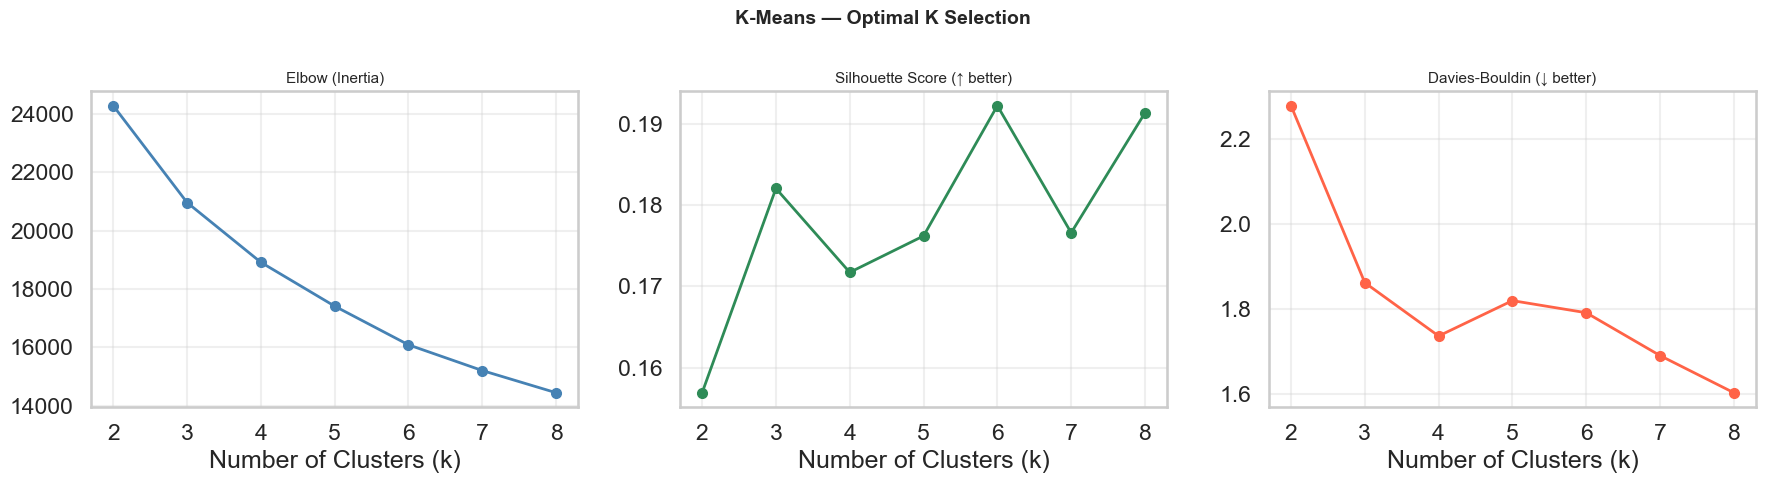

✔ Saved: A1_optimal_k.png



In [94]:
inertias, sil_scores, db_scores = [], [], []
k_range = range(2, max_k + 1)
 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=seed, n_init=10)
    lbl = km.fit_predict(X_km)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_km, lbl, sample_size=1500,
                                       random_state=seed))
    db_scores.append(davies_bouldin_score(X_km, lbl))
    print(f"  k={k:2d} | Inertia={km.inertia_:>10,.0f} | "
          f"Silhouette={sil_scores[-1]:.4f} | DB={db_scores[-1]:.4f}")
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("K-Means — Optimal K Selection", fontsize=14, fontweight="bold")
 
for ax, vals, title, color in zip(
    axes,
    [inertias, sil_scores, db_scores],
    ["Elbow (Inertia)", "Silhouette Score (↑ better)", "Davies-Bouldin (↓ better)"],
    ["steelblue", "seagreen", "tomato"]
):
    ax.plot(k_range, vals, "o-", color=color, linewidth=2, markersize=7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Number of Clusters (k)")
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(f"{output_dir}/A1_optimal_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: A1_optimal_k.png\n")

A2. Fit final K-Means model

In [95]:
best_k_km = int(np.argmax(sil_scores)) + 2   # +2 because k_range starts at 2
print(f"\n✔ Best k by silhouette = {best_k_km}")
 
km_final = KMeans(n_clusters=best_k_km, random_state=seed, n_init=10)
ht_risk_df["km_cluster"] = km_final.fit_predict(X_km)
 
print(f"  Silhouette    : {silhouette_score(X_km, ht_risk_df['km_cluster']):.4f}")
print(f"  Davies-Bouldin: {davies_bouldin_score(X_km, ht_risk_df['km_cluster']):.4f}")
print(f"\nCluster sizes:\n{ht_risk_df['km_cluster'].value_counts().sort_index().to_string()}\n")


✔ Best k by silhouette = 6
  Silhouette    : 0.1921
  Davies-Bouldin: 1.7913

Cluster sizes:
km_cluster
0    292
1    692
2    636
3    627
4    618
5    697



A3. Cluster feature profiles — heatmap

K-Means Cluster Profiles (raw feature means):
               age   male     bmi  poverty_income_ratio  physically_active  drinks_alcohol  ever_smoker  high_cholesterol
km_cluster                                                                                                               
0          52.1960 0.3730 29.2600                2.4750             0.3250          0.0000       0.1710            0.4140
1          61.2290 0.3950 30.3730                3.4900             0.4320          1.0000       0.0000            1.0000
2          41.9820 0.4870 28.1910                3.2140             1.0000          1.0000       0.0000            0.0200
3          62.2490 0.5420 30.4060                2.8140             0.3720          1.0000       1.0000            1.0000
4          45.0170 0.3170 30.4020                3.0050             0.0000          1.0000       0.0000            0.0230
5          51.4900 0.5380 28.9940                2.7320             0.4150          1.0000       1.0

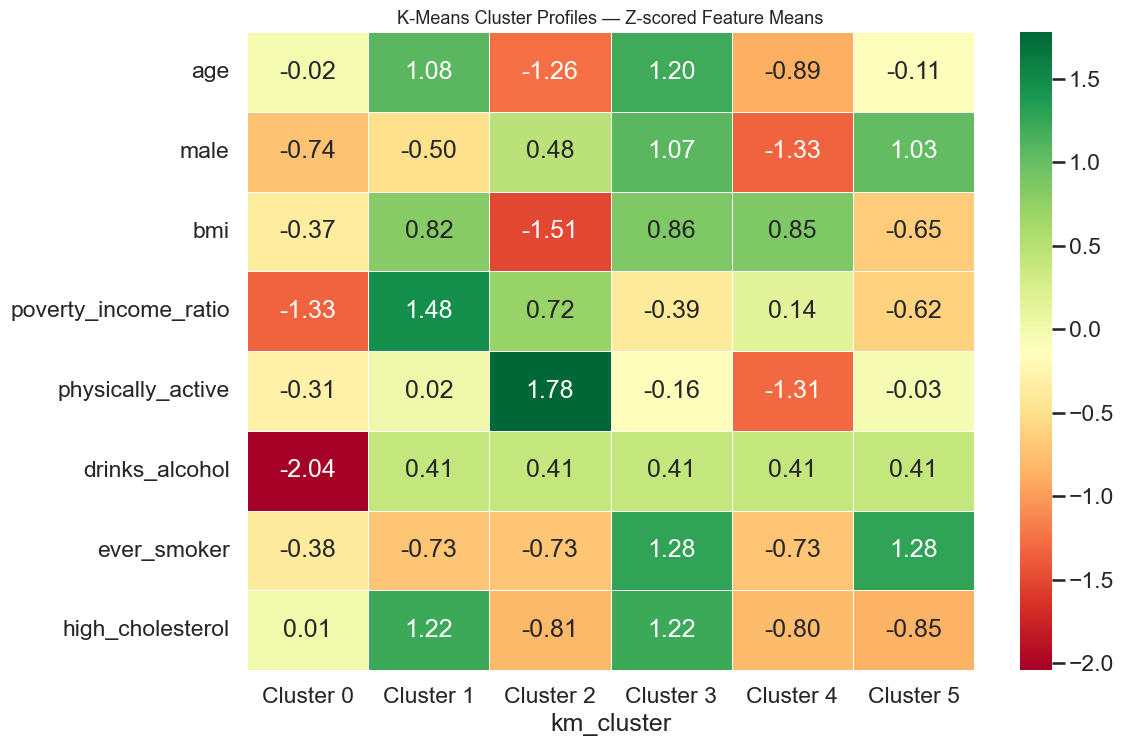

✔ Saved: A2_kmeans_profile_heatmap.png



In [96]:
km_profile = ht_risk_df.groupby("km_cluster")[kmeans_features].mean().round(3)
print("K-Means Cluster Profiles (raw feature means):")
print(km_profile.to_string(), "\n")
 
km_z = (km_profile - km_profile.mean()) / km_profile.std()
fig, ax = plt.subplots(figsize=(12, max(4, best_k_km * 1.3)))
sns.heatmap(km_z.T, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=ax,
            xticklabels=[f"Cluster {i}" for i in range(best_k_km)])
ax.set_title("K-Means Cluster Profiles — Z-scored Feature Means", fontsize=13)
plt.tight_layout()
plt.savefig(f"{output_dir}/A2_kmeans_profile_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: A2_kmeans_profile_heatmap.png\n")

A4. Post-hoc: hypertension risk rate by cluster

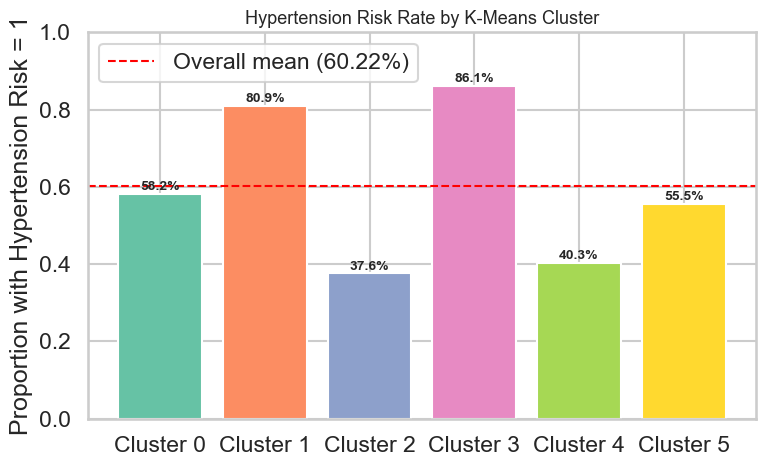

✔ Saved: A3_htn_risk_by_cluster.png



In [97]:
htn_by_cluster = ht_risk_df.groupby("km_cluster")["hypertension_risk"].mean().reset_index()
htn_by_cluster.columns = ["cluster", "hypertension_rate"]
overall_rate = ht_risk_df["hypertension_risk"].mean()
 
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [f"Cluster {i}" for i in htn_by_cluster["cluster"]],
    htn_by_cluster["hypertension_rate"],
    color=sns.color_palette(palette, best_k_km)
)
ax.axhline(overall_rate, color="red", linestyle="--", linewidth=1.5,
           label=f"Overall mean ({overall_rate:.2%})")
ax.set_ylabel("Proportion with Hypertension Risk = 1")
ax.set_title("Hypertension Risk Rate by K-Means Cluster", fontsize=13)
ax.set_ylim(0, 1)
for bar, val in zip(bars, htn_by_cluster["hypertension_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.1%}", ha="center", fontsize=10, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{output_dir}/A3_htn_risk_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: A3_htn_risk_by_cluster.png\n")

A5. Post-hoc: race/ethnicity composition per cluster

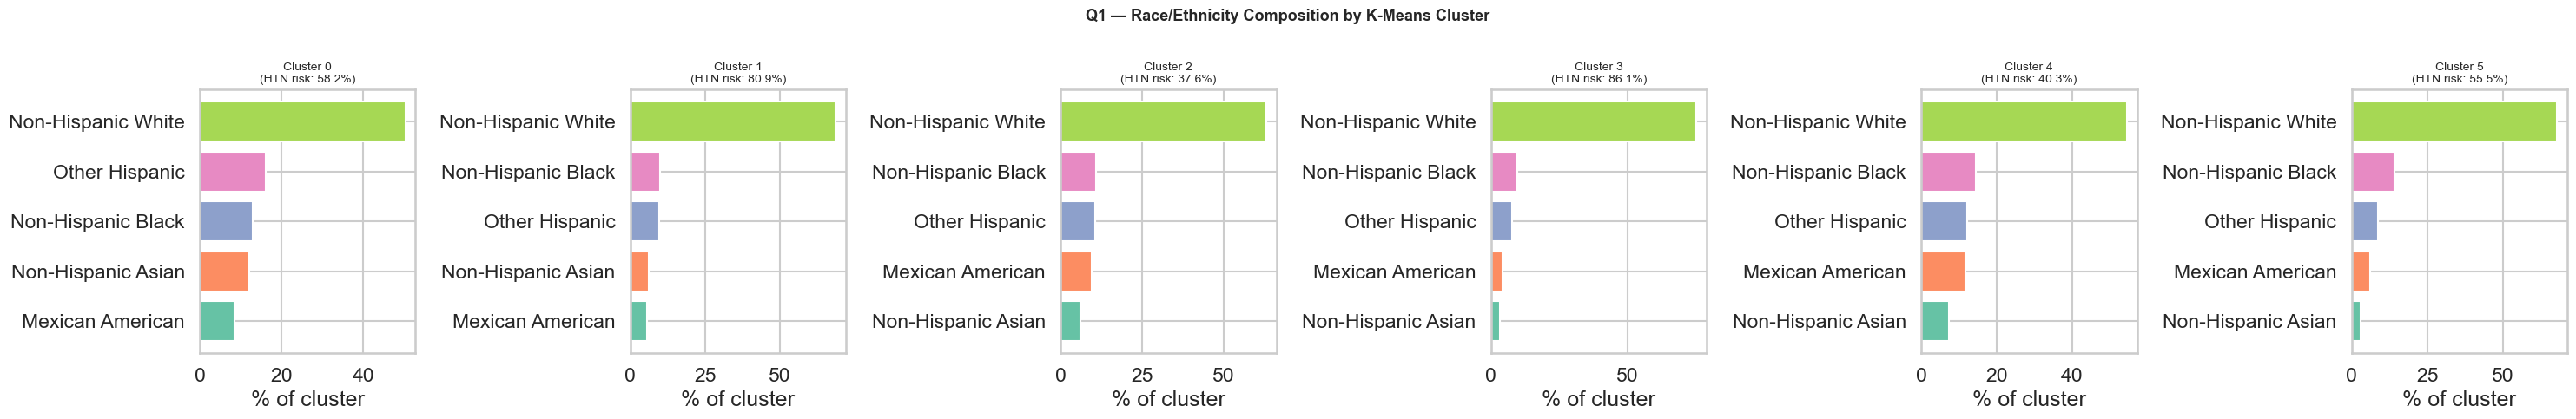

✔ Saved: A4_race_by_cluster.png



In [98]:
race_cluster = (ht_risk_df.groupby(["km_cluster", "race_ethnicity"])
                  .size().reset_index(name="count"))
race_cluster["pct"] = (race_cluster
                       .groupby("km_cluster")["count"]
                       .transform(lambda x: x / x.sum()) * 100)
 
fig, axes = plt.subplots(1, best_k_km,
                         figsize=(5 * best_k_km, 5), sharey=False)
if best_k_km == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    sub = race_cluster[race_cluster["km_cluster"] == i].sort_values("pct", ascending=True)
    ax.barh(sub["race_ethnicity"], sub["pct"],
            color=sns.color_palette(palette, len(sub)))
    htn_rate = ht_risk_df[ht_risk_df["km_cluster"] == i]["hypertension_risk"].mean()
    ax.set_title(f"Cluster {i}\n(HTN risk: {htn_rate:.1%})", fontsize=10)
    ax.set_xlabel("% of cluster")
 
fig.suptitle("Q1 — Race/Ethnicity Composition by K-Means Cluster",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{output_dir}/A4_race_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: A4_race_by_cluster.png\n")

A6. Gender disparity by cluster

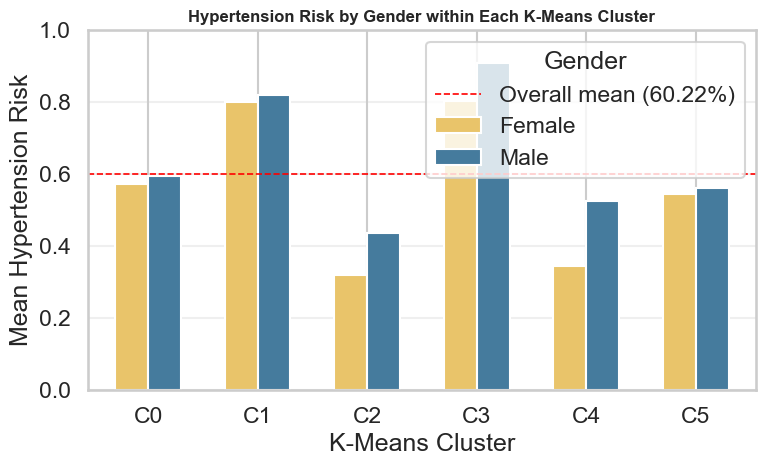

✔ Saved: A5_gender_disparity.png



In [99]:
gender_htn = ht_risk_df.groupby(["male", "km_cluster"])["hypertension_risk"].mean().reset_index()
gender_htn["gender"] = gender_htn["male"].map({1: "Male", 0: "Female"})
pivot_g = gender_htn.pivot(index="km_cluster", columns="gender",
                            values="hypertension_risk")
 
fig, ax = plt.subplots(figsize=(8, 5))
pivot_g.plot(kind="bar", ax=ax, color=["#e9c46a", "#457b9d"],
             edgecolor="white", width=0.6)
ax.axhline(overall_rate, color="red", linestyle="--", linewidth=1.2,
           label=f"Overall mean ({overall_rate:.2%})")
ax.set_title("Hypertension Risk by Gender within Each K-Means Cluster",
             fontsize=12, fontweight="bold")
ax.set_xlabel("K-Means Cluster")
ax.set_ylabel("Mean Hypertension Risk")
ax.set_xticklabels([f"C{i}" for i in range(best_k_km)], rotation=0)
ax.set_ylim(0, 1)
ax.legend(title="Gender")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/A5_gender_disparity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: A5_gender_disparity.png\n")

A7. Age distribution across clusters

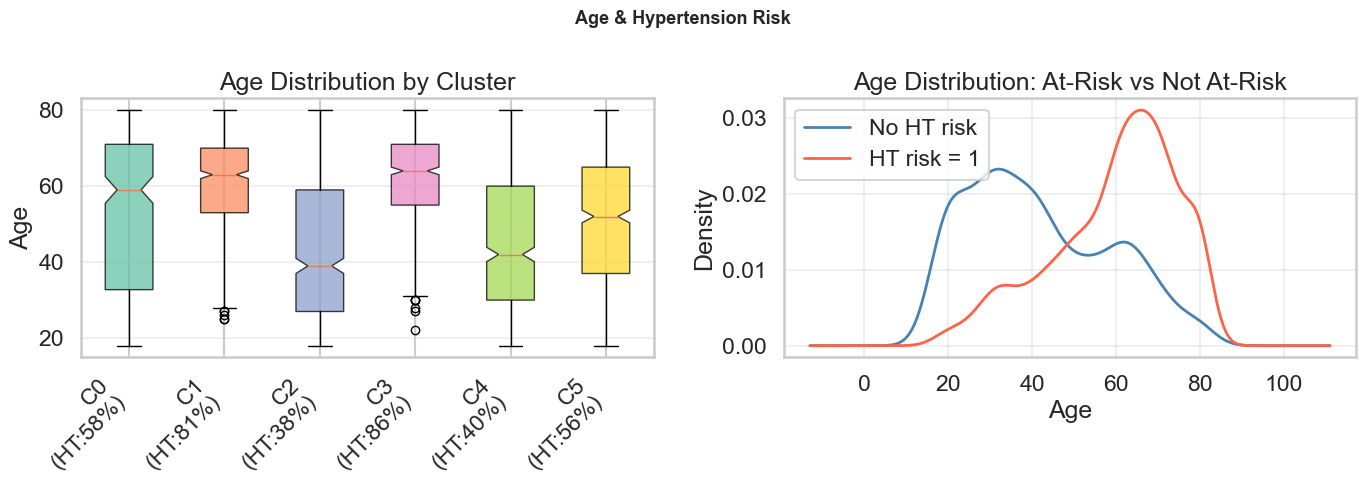

✔ Saved: A6_age_analysis.png



In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Age & Hypertension Risk", fontsize=13, fontweight="bold")
 
# Left: age boxplot per cluster (labelled with HTN rate)
data_age = [ht_risk_df[ht_risk_df["km_cluster"] == i]["age"].dropna().values
            for i in range(best_k_km)]
bp = axes[0].boxplot(data_age, patch_artist=True, notch=True)
colors = sns.color_palette(palette, best_k_km)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
htn_rates_km = [ht_risk_df[ht_risk_df["km_cluster"] == i]["hypertension_risk"].mean()
                for i in range(best_k_km)]
axes[0].set_xticklabels([f"C{i}\n(HT:{r:.0%})" for i, r in enumerate(htn_rates_km)], rotation=45, ha="right")
axes[0].set_title("Age Distribution by Cluster")
axes[0].set_ylabel("Age")
axes[0].grid(axis="y", alpha=0.3)
 
# Right: age KDE by HTN risk status (full dataset)
ht_risk_df[ht_risk_df["hypertension_risk"] == 0]["age"].dropna().plot.kde(
    ax=axes[1], label="No HT risk", color="steelblue", linewidth=2)
ht_risk_df[ht_risk_df["hypertension_risk"] == 1]["age"].dropna().plot.kde(
    ax=axes[1], label="HT risk = 1", color="tomato", linewidth=2)
axes[1].set_title("Age Distribution: At-Risk vs Not At-Risk")
axes[1].set_xlabel("Age")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(f"{output_dir}/A6_age_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: A6_age_analysis.png\n")

A8. Income & education

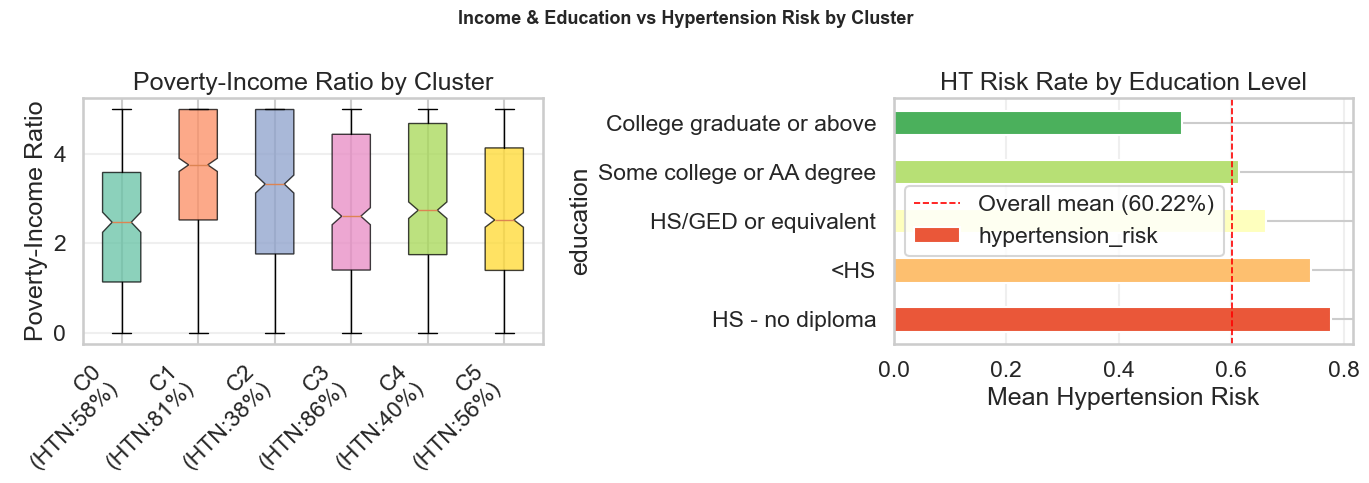

✔ Saved: A7_income_education.png



In [101]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Income & Education vs Hypertension Risk by Cluster",
             fontsize=13, fontweight="bold")
 
# Income boxplot per cluster
data_inc = [ht_risk_df[ht_risk_df["km_cluster"] == i]["poverty_income_ratio"].dropna().values
            for i in range(best_k_km)]
bp2 = axes[0].boxplot(data_inc, patch_artist=True, notch=True)
for patch, color in zip(bp2["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_xticklabels([f"C{i}\n(HTN:{r:.0%})" for i, r in enumerate(htn_rates_km)],rotation=45, ha="right")
axes[0].set_title("Poverty-Income Ratio by Cluster")
axes[0].set_ylabel("Poverty-Income Ratio")
axes[0].grid(axis="y", alpha=0.3)
 
# Education vs HTN rate (full dataset, no cluster split)
edu_htn = ht_risk_df.groupby("education")["hypertension_risk"].mean().sort_values(ascending=False)
edu_htn.plot(kind="barh", ax=axes[1],
             color=sns.color_palette("RdYlGn", len(edu_htn)))
axes[1].axvline(overall_rate, color="red", linestyle="--", linewidth=1.2,
                label=f"Overall mean ({overall_rate:.2%})")
axes[1].set_title("HT Risk Rate by Education Level")
axes[1].set_xlabel("Mean Hypertension Risk")
axes[1].legend()
axes[1].grid(axis="x", alpha=0.3)
 
plt.tight_layout()
plt.savefig(f"{output_dir}/A7_income_education.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: A7_income_education.png\n")

B. Hierarchical clustering (cosine similarity, average linkage)


In [102]:
print("━" * 65)
print("  PART B — HIERARCHICAL CLUSTERING (Cosine, Average Linkage)")
print("━" * 65)
 
X_hc, df_hc = preprocess(ht_risk_df, hclust_features, scale=True)
print(f"  Features : {hclust_features}")
print(f"  Shape    : {X_hc.shape}\n")
 
# Pairwise cosine distance matrix
print("  Computing pairwise cosine distances …")
cos_dist = pdist(X_hc, metric="cosine")
print(f"  {len(cos_dist):,} pairwise distances computed\n")
 
# Average linkage on cosine distances
Z = linkage(cos_dist, method="average")
print("  Linkage matrix computed (average linkage)\n")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PART B — HIERARCHICAL CLUSTERING (Cosine, Average Linkage)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Features : ['age', 'high_cholesterol', 'ever_smoker', 'physically_active', 'drinks_alcohol', 'male', 'bmi', 'poverty_income_ratio']
  Shape    : (3562, 8)

  Computing pairwise cosine distances …
  6,342,141 pairwise distances computed

  Linkage matrix computed (average linkage)



B1. Dendrogram (truncated for readability)

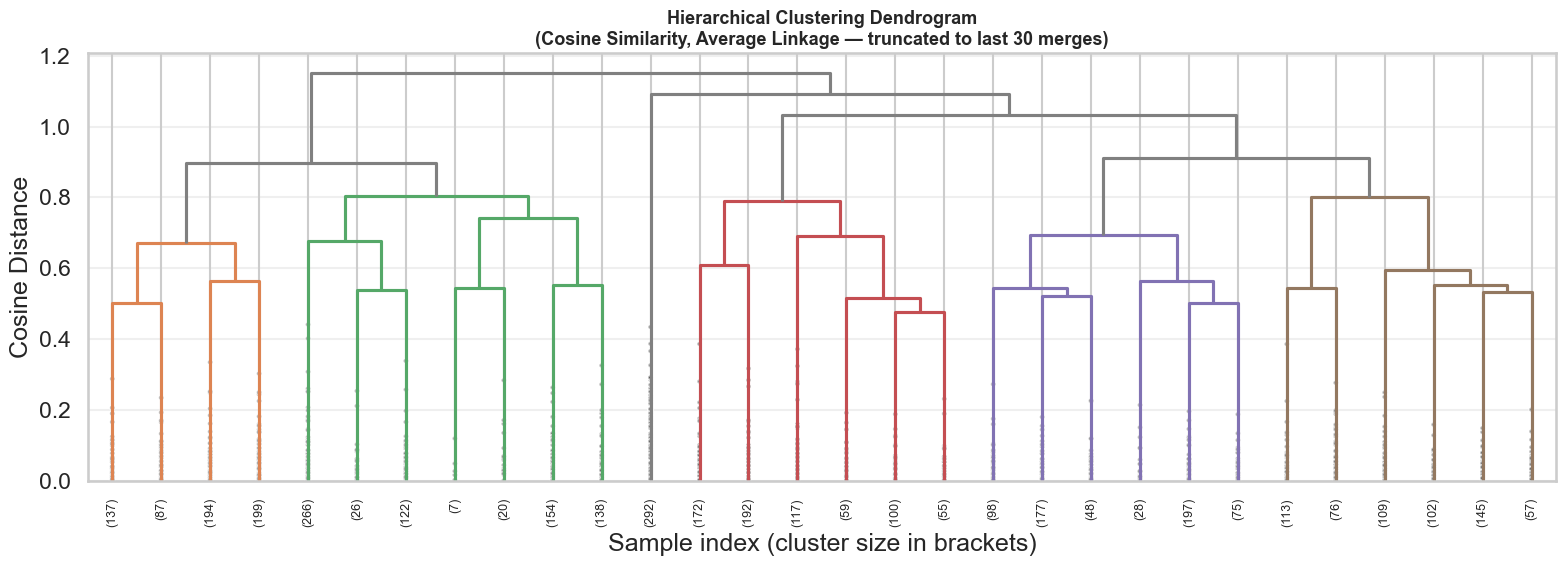

✔ Saved: B1_dendrogram.png



In [103]:
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    ax=ax,
    color_threshold=0.7 * max(Z[:, 2]),
    above_threshold_color="grey"
)
ax.set_title(
    "Hierarchical Clustering Dendrogram\n"
    "(Cosine Similarity, Average Linkage — truncated to last 30 merges)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Sample index (cluster size in brackets)")
ax.set_ylabel("Cosine Distance")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/B1_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: B1_dendrogram.png\n")
 

B2. Choose number of H-clusters via silhouette

  Evaluating silhouette scores (cosine) for each k …
  k= 2 | Silhouette (cosine) = 0.2570
  k= 3 | Silhouette (cosine) = 0.2750
  k= 4 | Silhouette (cosine) = 0.3029
  k= 5 | Silhouette (cosine) = 0.2911
  k= 6 | Silhouette (cosine) = 0.3329
  k= 7 | Silhouette (cosine) = 0.3268
  k= 8 | Silhouette (cosine) = 0.3170

✔ Best k by silhouette = 6



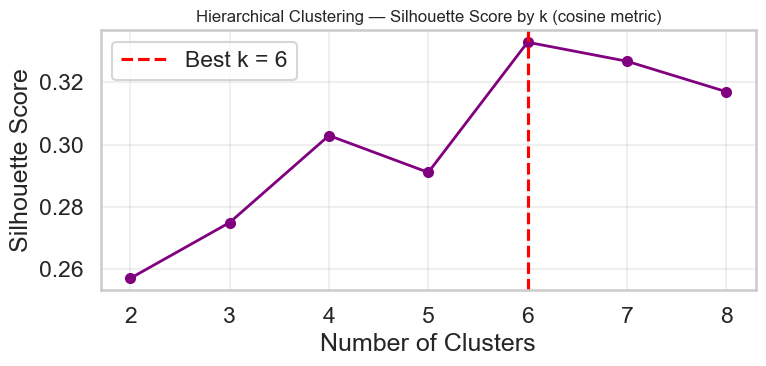

✔ Saved: B2_hclust_silhouette.png



In [104]:
print("  Evaluating silhouette scores (cosine) for each k …")
hc_sil = []
hc_range = range(2, max_k + 1)
 
for k in hc_range:
    lbl = fcluster(Z, k, criterion="maxclust") - 1
    s = silhouette_score(X_hc, lbl, metric="cosine",
                         sample_size=1500, random_state=seed)
    hc_sil.append(s)
    print(f"  k={k:2d} | Silhouette (cosine) = {s:.4f}")
 
best_k_hc = int(np.argmax(hc_sil)) + 2
print(f"\n✔ Best k by silhouette = {best_k_hc}\n")
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hc_range, hc_sil, "o-", color="purple", linewidth=2, markersize=7)
ax.axvline(best_k_hc, color="red", linestyle="--",
           label=f"Best k = {best_k_hc}")
ax.set_title("Hierarchical Clustering — Silhouette Score by k (cosine metric)",
             fontsize=12)
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Silhouette Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/B2_hclust_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: B2_hclust_silhouette.png\n")

B3. Assign cluster labels

In [105]:
ht_risk_df["hc_cluster"] = fcluster(Z, best_k_hc, criterion="maxclust") - 1
print(f"H-Cluster sizes:\n{ht_risk_df['hc_cluster'].value_counts().sort_index().to_string()}\n")

H-Cluster sizes:
hc_cluster
0    617
1    733
2    292
3    695
4    623
5    602



B4. H-Cluster risk factor profiles

H-Cluster Profiles (proportion with each binary risk factor = 1):
               age  high_cholesterol  ever_smoker  physically_active  drinks_alcohol   male     bmi  poverty_income_ratio
hc_cluster                                                                                                               
0          62.6160            1.0000       1.0000             0.3660          1.0000 0.5360 30.1480                2.7950
1          59.4220            0.9950       0.0140             0.4350          1.0000 0.4080 30.6510                3.4450
2          52.1960            0.4140       0.1710             0.3250          0.0000 0.3730 29.2600                2.4750
3          51.4530            0.0000       1.0000             0.4160          1.0000 0.5400 28.9000                2.7340
4          42.3170            0.0000       0.0000             1.0000          1.0000 0.4820 28.2580                3.2180
5          45.6760            0.0000       0.0030             0.0000          1.

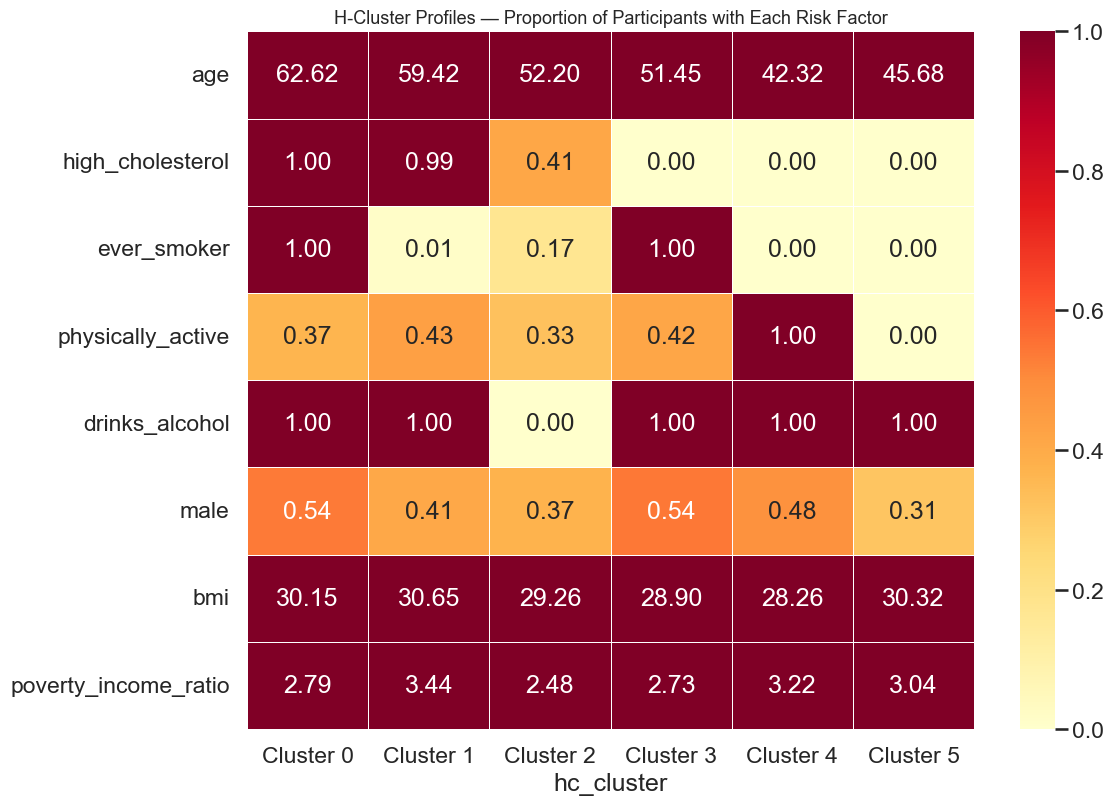

✔ Saved: B3_hclust_profile_heatmap.png



In [106]:
hc_profile = ht_risk_df.groupby("hc_cluster")[hclust_features].mean().round(3)
print("H-Cluster Profiles (proportion with each binary risk factor = 1):")
print(hc_profile.to_string(), "\n")
 
fig, ax = plt.subplots(figsize=(12, max(4, best_k_hc * 1.4)))
sns.heatmap(hc_profile.T, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax,
            xticklabels=[f"Cluster {i}" for i in range(best_k_hc)],
            vmin=0, vmax=1)
ax.set_title(
    "H-Cluster Profiles — Proportion of Participants with Each Risk Factor",
    fontsize=13
)
plt.tight_layout()
plt.savefig(f"{output_dir}/B3_hclust_profile_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Saved: B3_hclust_profile_heatmap.png\n")
 